In [3]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set(style="darkgrid")
import numpy as np
import scipy.stats

In [4]:
data = pd.read_csv('experiment-data.csv')
data

,PROG,TESTSUITEID,TESTID,TIME,P1X,P1Y,P2X,P2Y,P3X,P3Y,P4X,P4Y,P5X,P5Y,ISVALID,PASSED,MAX_BOLP
0,ALG1,1,1,4.95,29.49,56.63,35.54,40.80,15.93,42.84,45.30,68.17,55.53,61.76,Y,Y,0.068
1,ALG1,1,2,4.96,17.41,23.48,16.67,6.47,37.71,0.00,0.00,4.32,0.00,0.00,N,NaN,0.000
2,ALG1,1,3,5.61,51.75,0.00,51.36,43.69,63.37,28.66,60.14,38.17,67.39,17.30,N,NaN,0.000
3,ALG1,1,4,5.54,19.78,0.00,29.69,1.80,15.08,0.00,16.10,0.00,0.00,0.00,N,NaN,0.000
4,ALG1,1,5,5.93,34.65,0.00,6.14,13.26,18.70,20.92,14.24,15.71,32.23,32.43,N,NaN,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,ALG4,30,496,25.31,49.43,0.00,51.00,0.00,50.22,0.00,51.55,0.14,51.55,0.00,Y,N,0.673
59996,ALG4,30,497,25.20,49.93,0.00,50.10,0.00,51.93,0.44,52.93,0.08,52.00,0.91,Y,N,0.960
59997,ALG4,30,498,25.11,49.30,0.00,48.58,0.54,48.31,0.61,49.69,0.89,50.13,0.00,Y,N,0.831
59998,ALG4,30,499,25.11,50.81,0.19,51.49,0.00,50.06,1.44,50.96,1.30,52.49,1.44,N,NaN,0.000


In [40]:
passed_counts = data.groupby('PROG')['PASSED'].value_counts(dropna=False)
passed_counts

PROG  PASSED
ALG1  NaN        9705
      Y          3033
      N          2262
ALG2  NaN       10618
      Y          3281
      N          1101
ALG3  NaN        8979
      N          5087
      Y           934
ALG4  NaN       10467
      N          4515
      Y            18
Name: count, dtype: int64

In [5]:
df = data[['PROG', 'TESTSUITEID', 'TIME']]
df = df.groupby(['PROG', 'TESTSUITEID'])['TIME'].sum().reset_index()
df.head(3)

,PROG,TESTSUITEID,TIME
0,ALG1,1,15037.62
1,ALG1,2,15042.74
2,ALG1,3,15040.67


#### relevant descriptive statistics for the test suite generation time variable,
#### including sample mean, median, standard deviation, min, max.

In [31]:
df_describe = df.groupby('PROG')['TIME'].describe()
df_sum = df.groupby('PROG')['TIME'].sum().rename('sum')
df_median = df.groupby('PROG')['TIME'].median().rename('median')
df_describe = df_describe.join([df_median,df_sum])
df_describe

,count,mean,std,min,25%,50%,75%,max,median,sum
PROG,,,,,,,,,,
ALG1,30.0,15039.234333,4.653653,15027.05,15036.5950,15040.000,15041.6775,15050.31,15040.000,451177.03
ALG2,30.0,166.997000,3.859926,154.96,164.9175,166.675,169.2575,175.04,166.675,5009.91
ALG3,30.0,1421.180000,4.106206,1413.57,1417.4400,1421.700,1424.8700,1427.88,1421.700,42635.40
ALG4,30.0,6431.182333,4.392053,6422.81,6428.9675,6430.695,6432.5875,6442.42,6430.695,192935.47


#### create a histogram ( plot of testsuites)

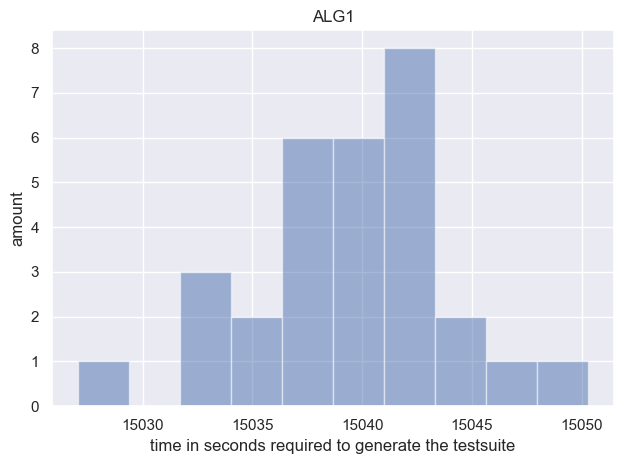

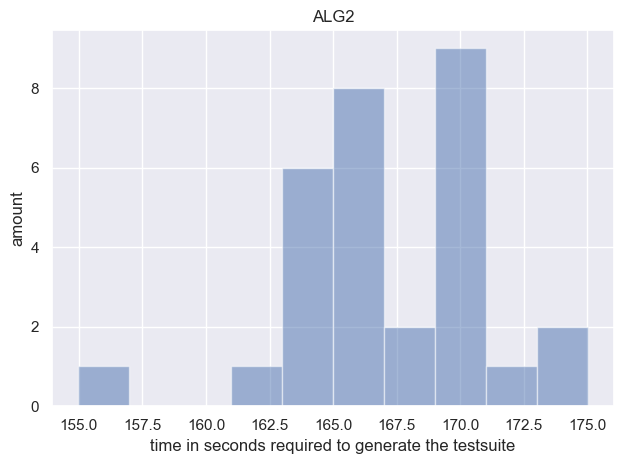

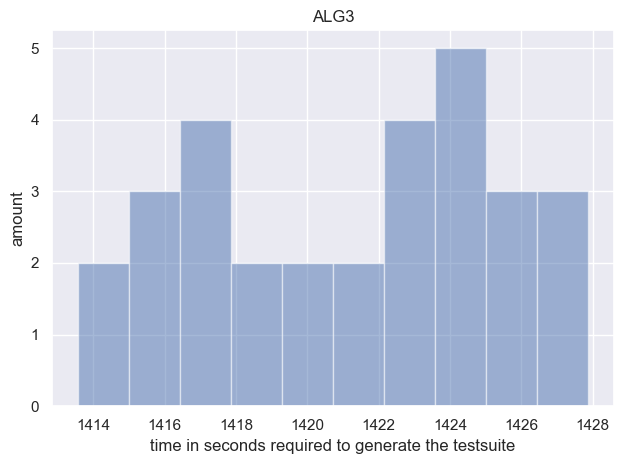

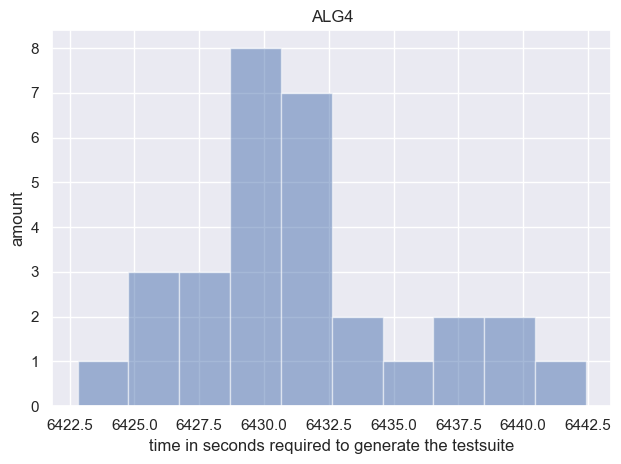

In [29]:
algorithms = df['PROG'].unique()
NALG = len(algorithms)
for alg in algorithms:
    plt.figure()
    subset = df[df['PROG'] == alg]['TIME']
    plt.hist(subset, bins=10, alpha=0.5)

    plt.xlabel('time in seconds required to generate the testsuite')
    plt.ylabel("amount")
    plt.title(f"{alg}")
    plt.tight_layout()
    plt.show()
    

### boxplot for each algorithms (with time on Y axis)

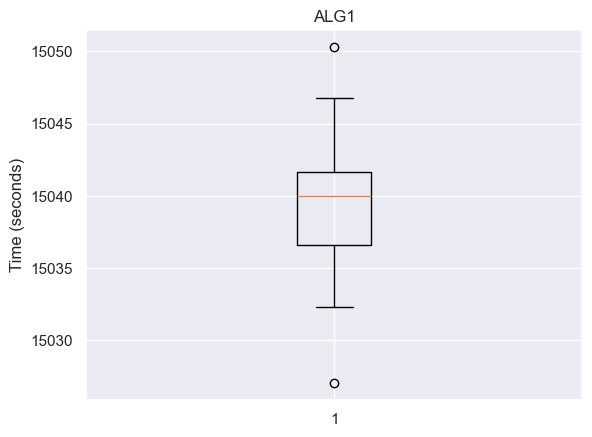

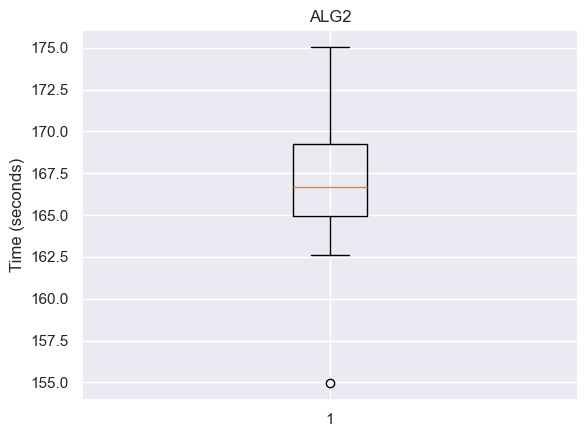

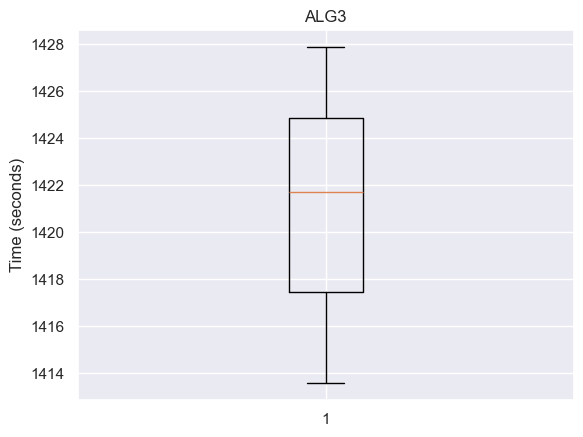

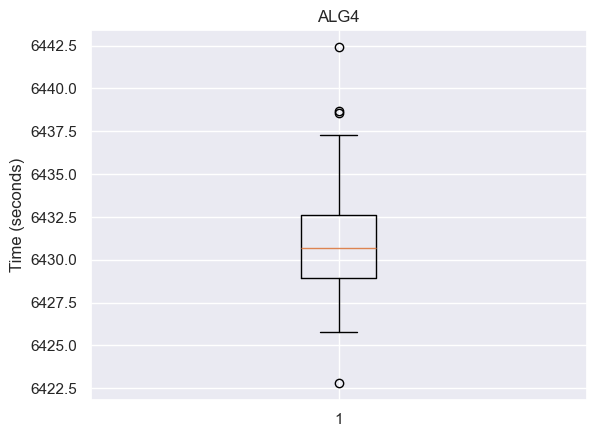

In [42]:
for alg in algorithms:
    plt.figure()
    subset = df[df['PROG'] == alg]['TIME']
    plt.boxplot(subset)
    plt.ylabel("Time (seconds)")
    plt.title(f"{alg}")
    plt.show()

### What algorithm produces test suits faster (time to generate a complete test suite)?

Algorithm 2 is the fastest by a large margin with an average execution time of about 167 seconds to generate and test suite. Also it has the lowest standard deviation which indicates it is performing consistently the same speed.